importing dependencies


In [13]:
!pip install xgboost imbalanced-learn

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [15]:
df = pd.read_csv("creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

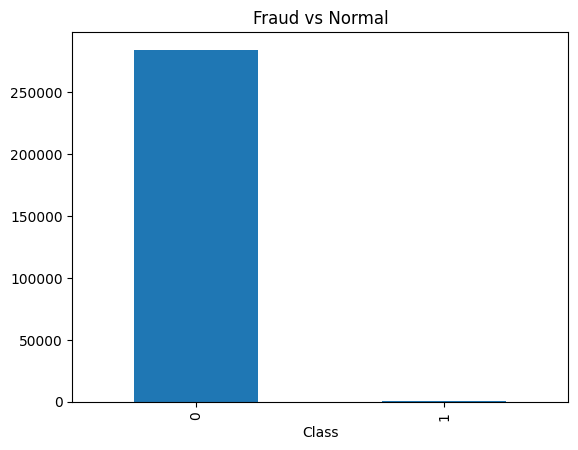

In [16]:
df['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Normal")
plt.show()

In [17]:
smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_res = scaler.fit_transform(X_res)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42
)

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "XGBoost": XGBClassifier(n_estimators=50)
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    accuracies[name] = acc

    print("Model:", name)
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))
    print("------------")

Model: Logistic Regression
Accuracy: 0.9800045723932962
[[56227   523]
 [ 1751 55225]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56750
           1       0.99      0.97      0.98     56976

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726

------------
Model: Random Forest
Accuracy: 0.9999208624237201
[[56741     9]
 [    0 56976]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

------------
Model: XGBoost
Accuracy: 0.9996922427589118
[[56715    35]
 [    0 56976]]
              precision    recall  f1-score   support

           0       1.0

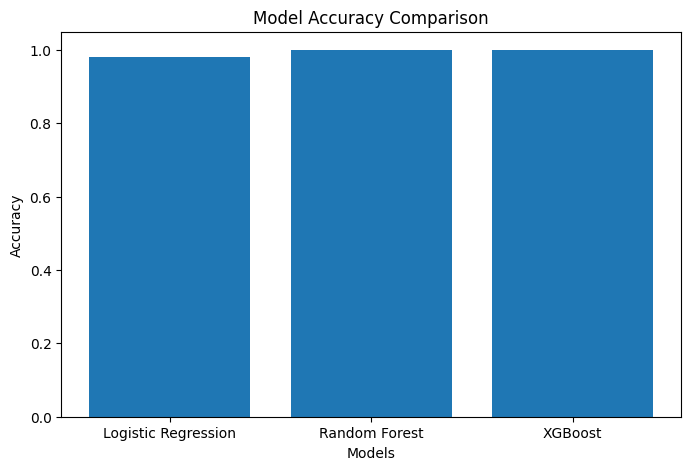

In [21]:
plt.figure(figsize=(8,5))

plt.bar(accuracies.keys(), accuracies.values())

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

In [22]:
best_model_name = max(accuracies, key=accuracies.get)

print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Random Forest


In [23]:
import joblib
joblib.dump(best_model, "fraud_model.pkl")

['fraud_model.pkl']

In [24]:
from google.colab import files
files.download("fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>